# Testing Global Folding / Global Injectivity in Deformation Fields

## Background

A deformation field is **globally injective** (fold-free) if no two distinct fixed-space
voxels map to the same moving-space location.  The textbook hierarchy is:

```
Monotonicity  ⟹  Global injectivity  ⟹  Local injectivity (positive Jdet)
```

However, **monotonicity only implies global injectivity of the *nodal map***, not
of the discrete bilinear quad-cell mesh.  Monotonicity constrains each row's
x-coords and each column's y-coords independently; it does not prevent cells from
*different rows* meeting at a pinch-point and crossing.  This notebook implements
four tests that cover both local and global failure modes:

| # | Test | Detects | Strength |
|---|------|---------|----------|
| 1 | **Jacobian det > 0** (central differences, `np.gradient`) | approximate local fold | weakest — can miss "checkerboard" folds |
| 2 | **Shoelace area > 0** (exact quad-cell signed area) | exact local cell fold | exact local test |
| 3 | **Monotonicity** (`1 + forward-diff > 0`) | deformed coords non-monotone | necessary but not sufficient for mesh-level global injectivity |
| 4 | **Quad self-intersection** (edge-edge + winding number) | non-adjacent cells overlap | necessary and sufficient for global injectivity |

### Why Jdet (central differences) can miss folds

Consider an **alternating checkerboard displacement** `dx[j] = A·(−1)ʲ` with `0.5 < A < 1`:
- Deformed x-coords: `0+A, 1−A, 2+A, 3−A, …` — every even→odd cell is reversed (folded).
- Shoelace area of each even→odd cell: `1−2A < 0` → **fold detected**.
- `np.gradient` at interior node `j`: central diff averages the two-neighbour span,
  giving `(def_x[j+1]−def_x[j−1])/2 = ((j+1±A) − (j−1∓A))/2 = 1+A > 0` → **Jdet passes**!

### Why diagonal-triangulation gives false positives at pinch-points

Splitting a quad (TL,TR,BR,BL) along the TL→BR diagonal is only valid when the quad
is convex.  Under large shear, a quad with positive shoelace area can be non-convex —
the diagonal then exits the quad's true boundary, and the resulting triangles over-cover
the cell.  This causes the triangle-based test to flag near-touching pinch-point cells
as intersecting when they are not.  The fix is to test boundary edges directly and use
a winding-number containment check, which is exact for any simple polygon.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Polygon as MplPoly

from dvfopt import jacobian_det2D, iterative_serial
from dvfopt._defaults import DEFAULT_PARAMS
from dvfopt.jacobian import _monotonicity_diffs_2d, _diagonal_monotonicity_diffs_2d, shoelace_det2D
from dvfopt.testcases import SYNTHETIC_CASES, RANDOM_DVF_CASES, make_deformation, make_random_dvf

THRESHOLD = DEFAULT_PARAMS["threshold"]        # Jdet lower bound used by the corrector
INJECTIVITY_THRESHOLD = 0.3  # vertex-separation lower bound for injectivity constraints

---
## Implementation

### Geometry primitives for the self-intersection test

In [ ]:
def _cross2d(o, a, b):
    """Signed area of parallelogram OA x OB.  Points are (x, y) tuples."""
    return (a[0]-o[0])*(b[1]-o[1]) - (a[1]-o[1])*(b[0]-o[0])


def _segs_cross(p, q, r, s):
    """True iff segment PQ *properly* crosses segment RS (interior-to-interior)."""
    d1 = _cross2d(r, s, p)
    d2 = _cross2d(r, s, q)
    d3 = _cross2d(p, q, r)
    d4 = _cross2d(p, q, s)
    return (d1 * d2 < 0) and (d3 * d4 < 0)


def _winding_number(pt, poly):
    """Winding number of *pt* w.r.t. simple polygon *poly* (list of (x,y) points).

    Returns 0 outside, non-zero inside.  Works correctly for convex AND
    non-convex polygons — no diagonal triangulation needed.
    """
    wn = 0
    n = len(poly)
    for i in range(n):
        p1, p2 = poly[i], poly[(i + 1) % n]
        if p1[1] <= pt[1]:
            if p2[1] > pt[1]:                  # upward crossing
                if _cross2d(p1, p2, pt) > 0:   # pt strictly left of edge
                    wn += 1
        else:
            if p2[1] <= pt[1]:                 # downward crossing
                if _cross2d(p1, p2, pt) < 0:   # pt strictly right of edge
                    wn -= 1
    return wn


def _quads_intersect(q1, q2):
    """True iff the interiors of quads q1 and q2 (each 4 (x,y) pts, TL→TR→BR→BL)
    genuinely overlap.

    Strategy
    --------
    1. Check all 16 boundary-edge pairs for a proper interior crossing.
    2. Winding-number containment: test one vertex of each quad against the other
       (handles the case where one quad is entirely inside the other).

    This avoids the false positives produced by the diagonal-triangulation
    approach, which over-covers non-convex quads (e.g. thin wedges at
    pinch-points in severely warped grids) and clips into neighbouring cells.
    """
    edges1 = [(q1[i], q1[(i + 1) % 4]) for i in range(4)]
    edges2 = [(q2[i], q2[(i + 1) % 4]) for i in range(4)]

    # 1. Proper edge-edge crossing
    for e1 in edges1:
        for e2 in edges2:
            if _segs_cross(*e1, *e2):
                return True

    # 2. Containment (one quad entirely inside the other)
    if _winding_number(q1[0], q2) != 0:
        return True
    if _winding_number(q2[0], q1) != 0:
        return True

    return False

### `check_global_injectivity_2d`

In [3]:
def check_global_injectivity_2d(phi, check_intersections=True, verbose=True):
    """Run four injectivity tests on a (2, H, W) deformation field phi = [dy, dx].

    All tests use strict positivity (> 0) as the criterion — this is the
    mathematical condition for injectivity, independent of the corrector's
    engineering threshold (0.01).

    Returns
    -------
    dict with keys:
        local_jdet_ok      — all interior central-diff Jdets > 0
        shoelace_ok        — all interior quad signed areas > 0  (exact)
        monotone_ok        — all monotonicity diffs > 0 (h, v, and diagonal)
        globally_injective — no non-adjacent quad cell pairs intersect
        details            — per-pixel maps + list of intersecting pairs
    """
    dy, dx = phi[0], phi[1]
    H, W = dy.shape

    yy, xx = np.mgrid[0:H, 0:W].astype(float)
    def_y = yy + dy
    def_x = xx + dx

    # ---- 1. Jacobian det (central differences) — strict positivity ----
    jac = np.squeeze(jacobian_det2D(phi))             # (H, W)
    n_neg_jac  = int((jac[1:-1, 1:-1] <= 0).sum())

    # ---- 2. Shoelace signed quad areas (exact) — strict positivity ----
    shoe = np.squeeze(shoelace_det2D(phi))            # (H-1, W-1)
    n_neg_shoe = int((shoe[1:-1, 1:-1] <= 0).sum())

    # ---- 3. Monotonicity (forward differences) — strict positivity ----
    h_mono, v_mono = _monotonicity_diffs_2d(dy, dx)       # (H, W-1) and (H-1, W)
    d1, d2 = _diagonal_monotonicity_diffs_2d(dy, dx)      # (H-1, W-1) each
    n_h_viol  = int((h_mono[1:-1, 1:-1] <= 0).sum())
    n_v_viol  = int((v_mono[1:-1, 1:-1] <= 0).sum())
    n_d1_viol = int((d1[1:-1, 1:-1] <= 0).sum())
    n_d2_viol = int((d2[1:-1, 1:-1] <= 0).sum())

    # ---- 4. Quad self-intersection ----
    intersecting_pairs = []
    if check_intersections:
        cells = []
        for i in range(H - 1):
            for j in range(W - 1):
                pts = [
                    (float(def_x[i,   j]),   float(def_y[i,   j])),
                    (float(def_x[i,   j+1]), float(def_y[i,   j+1])),
                    (float(def_x[i+1, j+1]), float(def_y[i+1, j+1])),
                    (float(def_x[i+1, j]),   float(def_y[i+1, j])),
                ]
                xs = [p[0] for p in pts]; ys = [p[1] for p in pts]
                cells.append(((i, j), pts, min(xs), max(xs), min(ys), max(ys)))

        for k1, ((i1, j1), q1, xmin1, xmax1, ymin1, ymax1) in enumerate(cells):
            for k2 in range(k1 + 1, len(cells)):
                (i2, j2), q2, xmin2, xmax2, ymin2, ymax2 = cells[k2]
                if abs(i1 - i2) <= 1 and abs(j1 - j2) <= 1:
                    continue
                if xmax1 < xmin2 or xmax2 < xmin1 or ymax1 < ymin2 or ymax2 < ymin1:
                    continue
                if _quads_intersect(q1, q2):
                    intersecting_pairs.append(((i1, j1), (i2, j2)))

    result = {
        'local_jdet_ok':       n_neg_jac == 0,
        'shoelace_ok':         n_neg_shoe == 0,
        'monotone_ok':         n_h_viol == 0 and n_v_viol == 0 and n_d1_viol == 0 and n_d2_viol == 0,
        'globally_injective':  len(intersecting_pairs) == 0,
        'details': {
            'n_neg_jac':          n_neg_jac,
            'n_neg_shoe':         n_neg_shoe,
            'n_h_mono_viol':      n_h_viol,
            'n_v_mono_viol':      n_v_viol,
            'n_d1_mono_viol':     n_d1_viol,
            'n_d2_mono_viol':     n_d2_viol,
            'n_intersecting':     len(intersecting_pairs),
            'intersecting_pairs': intersecting_pairs,
            'jac':    jac,
            'shoe':   shoe,
            'h_mono': h_mono,
            'v_mono': v_mono,
            'd1':     d1,
            'd2':     d2,
            'def_y':  def_y,
            'def_x':  def_x,
        },
    }

    if verbose:
        tick = lambda ok: "OK  " if ok else "FAIL"
        d = result['details']
        print(f"  Jdet > 0:          {tick(result['local_jdet_ok'])}  (n_fail={d['n_neg_jac']})")
        print(f"  Shoelace > 0:      {tick(result['shoelace_ok'])}  (n_fail={d['n_neg_shoe']})")
        print(f"  Monotonicity > 0:  {tick(result['monotone_ok'])}  "
              f"(h={d['n_h_mono_viol']}, v={d['n_v_mono_viol']}, "
              f"d1={d['n_d1_mono_viol']}, d2={d['n_d2_mono_viol']})")
        if check_intersections:
            print(f"  Self-intersection: {tick(result['globally_injective'])}  (n_pairs={d['n_intersecting']})")

    return result

### Visualisation helper

In [4]:
def plot_checks(phi, result, title=""):
    """2x2 panel: Jdet map | Shoelace map | Monotonicity violations | Self-intersecting pairs."""
    d = result['details']
    H, W = phi.shape[-2:]
    def_y, def_x = d['def_y'], d['def_x']

    fig, axes = plt.subplots(2, 2, figsize=(13, 10))

    # ---- Panel 1: Jacobian determinant ----
    ax = axes[0, 0]
    jac = d['jac']
    vext = max(abs(float(jac.min())), float(jac.max()), 0.5)
    im = ax.imshow(jac, cmap='bwr', vmin=-vext, vmax=vext, origin='upper')
    plt.colorbar(im, ax=ax)
    status = 'OK' if result['local_jdet_ok'] else f"FAIL (n={d['n_neg_jac']})"
    ax.set_title(f"Jacobian det (central diff)\n{status}", fontsize=10)

    # ---- Panel 2: Shoelace areas ----
    ax = axes[0, 1]
    shoe = d['shoe']   # (H-1, W-1)
    vext = max(abs(float(shoe.min())), float(shoe.max()), 0.5)
    im = ax.imshow(shoe, cmap='bwr', vmin=-vext, vmax=vext, origin='upper')
    plt.colorbar(im, ax=ax)
    status = 'OK' if result['shoelace_ok'] else f"FAIL (n={d['n_neg_shoe']})"
    ax.set_title(f"Shoelace cell area (exact)\n{status}", fontsize=10)

    # ---- Panel 3: Monotonicity violations on deformed grid ----
    ax = axes[1, 0]
    row_idx = list(range(H))
    col_idx = list(range(W))
    for i in row_idx:
        ax.plot(def_x[i, :], def_y[i, :], 'k-', linewidth=0.5, alpha=0.3)
    for j in col_idx:
        ax.plot(def_x[:, j], def_y[:, j], 'k-', linewidth=0.5, alpha=0.3)

    # Horizontal violations (red): edge from (i,j) to (i,j+1)
    h_viol = d['h_mono'] <= 0
    for i in range(H):
        for j in range(W - 1):
            if h_viol[i, j]:
                ax.plot([def_x[i, j], def_x[i, j+1]], [def_y[i, j], def_y[i, j+1]],
                        'r-', linewidth=2.5, zorder=3)

    # Vertical violations (blue): edge from (i,j) to (i+1,j)
    v_viol = d['v_mono'] <= 0
    for i in range(H - 1):
        for j in range(W):
            if v_viol[i, j]:
                ax.plot([def_x[i, j], def_x[i+1, j]], [def_y[i, j], def_y[i+1, j]],
                        'b-', linewidth=2.5, zorder=3)

    # Diagonal violations (green/orange): anti-diagonal of cell (r,c)
    # d1[r,c]: TR=(r,c+1) to BL=(r+1,c)
    d1_viol = d['d1'] <= 0
    d2_viol = d['d2'] <= 0
    for r in range(H - 1):
        for c in range(W - 1):
            if d1_viol[r, c] or d2_viol[r, c]:
                ax.plot([def_x[r, c+1], def_x[r+1, c]], [def_y[r, c+1], def_y[r+1, c]],
                        color='#e67e22', linewidth=2.5, zorder=4)

    ax.set_aspect('equal')
    ax.invert_yaxis()
    mono_ok = result['monotone_ok']
    h_n, v_n = d['n_h_mono_viol'], d['n_v_mono_viol']
    d1_n, d2_n = d['n_d1_mono_viol'], d['n_d2_mono_viol']
    status = 'OK' if mono_ok else f"FAIL (h={h_n}, v={v_n}, d1={d1_n}, d2={d2_n})"
    ax.set_title(f"Monotonicity violations\nred=h, blue=v, orange=diag  {status}", fontsize=10)

    # ---- Panel 4: Self-intersection (deformed grid + flagged pairs) ----
    ax = axes[1, 1]
    for i in row_idx:
        ax.plot(def_x[i, :], def_y[i, :], 'k-', linewidth=0.5, alpha=0.4)
    for j in col_idx:
        ax.plot(def_x[:, j], def_y[:, j], 'k-', linewidth=0.5, alpha=0.4)
    colours = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
    shown = d['intersecting_pairs'][:30]
    for k, ((i1, j1), (i2, j2)) in enumerate(shown):
        col = colours[k % len(colours)]
        for ri, rj in [(i1, j1), (i2, j2)]:
            corners = [(def_x[ri, rj], def_y[ri, rj]),
                       (def_x[ri, rj+1], def_y[ri, rj+1]),
                       (def_x[ri+1, rj+1], def_y[ri+1, rj+1]),
                       (def_x[ri+1, rj], def_y[ri+1, rj])]
            poly = MplPoly(corners, closed=True,
                           facecolor=col, alpha=0.35, edgecolor=col, linewidth=1.5)
            ax.add_patch(poly)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    n_pairs = d['n_intersecting']
    extra = " (showing first 30)" if n_pairs > 30 else ""
    status = 'OK' if result['globally_injective'] else f"FAIL ({n_pairs} pairs{extra})"
    ax.set_title(f"Quad self-intersections\n{status}", fontsize=10)

    if title:
        fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## Example 1 — Synthetic checkerboard field

Alternating displacement `dx[j] = A·(−1)ʲ` with `A = 0.7`.
- Every even→odd cell is locally folded (negative shoelace area).
- Central-difference Jdet **misses** all folds (averaging smooths them out).
- Monotonicity fails at every even column.
- Self-intersection test: the folds are purely between adjacent cells, which are
  skipped in the non-adjacent check — confirms the shoelace test is essential
  for detecting local folds.

=== Checkerboard field  (A=0.7, 0.5 < A < 1) ===
  Deformed x at row 0: [0.7, 0.30000000000000004, 2.7, 2.3, 4.7, 4.3, 6.7, 6.3, 8.7, 8.3]

  Jdet > 0:          OK    (n_fail=0)
  Shoelace > 0:      FAIL  (n_fail=21)
  Monotonicity > 0:  FAIL  (h=24, v=0, d1=21, d2=0)
  Self-intersection: FAIL  (n_pairs=27)


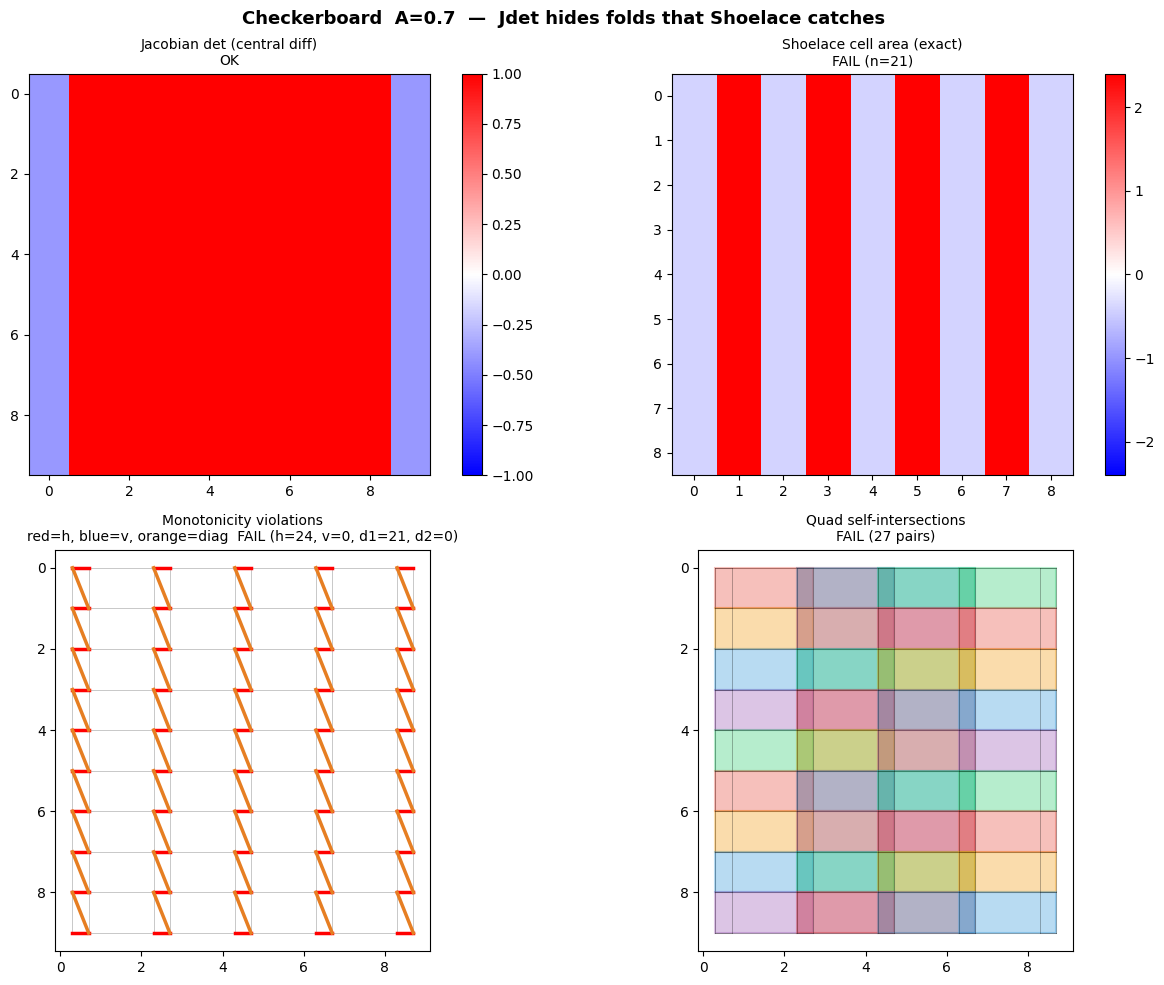

In [5]:
H, W = 10, 10
A = 0.7   # 0.5 < A < 1: Jdet passes, shoelace fails

dy_cb = np.zeros((H, W))
dx_cb = np.zeros((H, W))
dx_cb[:, ::2]  =  A    # even columns shift right
dx_cb[:, 1::2] = -A    # odd  columns shift left

phi_cb = np.stack([dy_cb, dx_cb])   # (2, H, W)

print("=== Checkerboard field  (A=0.7, 0.5 < A < 1) ===")
print(f"  Deformed x at row 0: {(np.arange(W) + dx_cb[0]).tolist()}")
print()
result_cb = check_global_injectivity_2d(phi_cb)
plot_checks(phi_cb, result_cb, title=f"Checkerboard  A={A}  —  Jdet hides folds that Shoelace catches")

---
## Example 2 — Original synthetic test cases

Run all four tests on the unmodified Laplacian deformation fields.


=== Case 1a — 10×10 crossing points ===
  Jdet > 0:          FAIL  (n_fail=9)
  Shoelace > 0:      FAIL  (n_fail=10)
  Monotonicity > 0:  FAIL  (h=12, v=0, d1=10, d2=0)
  Self-intersection: FAIL  (n_pairs=75)


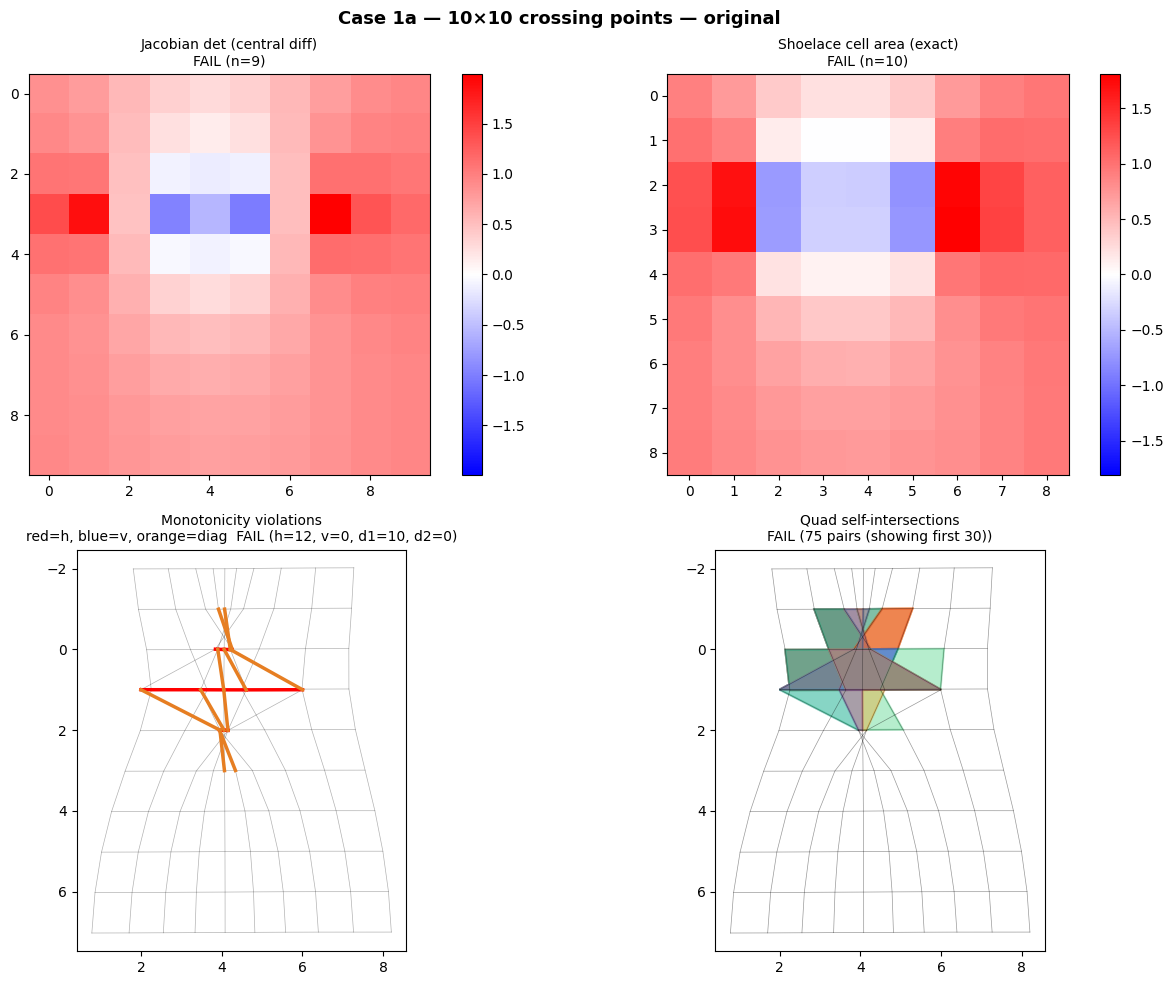


=== Case 1c — 20×40 edges ===
  Jdet > 0:          FAIL  (n_fail=29)
  Shoelace > 0:      FAIL  (n_fail=32)
  Monotonicity > 0:  FAIL  (h=15, v=15, d1=19, d2=20)
  Self-intersection: FAIL  (n_pairs=337)


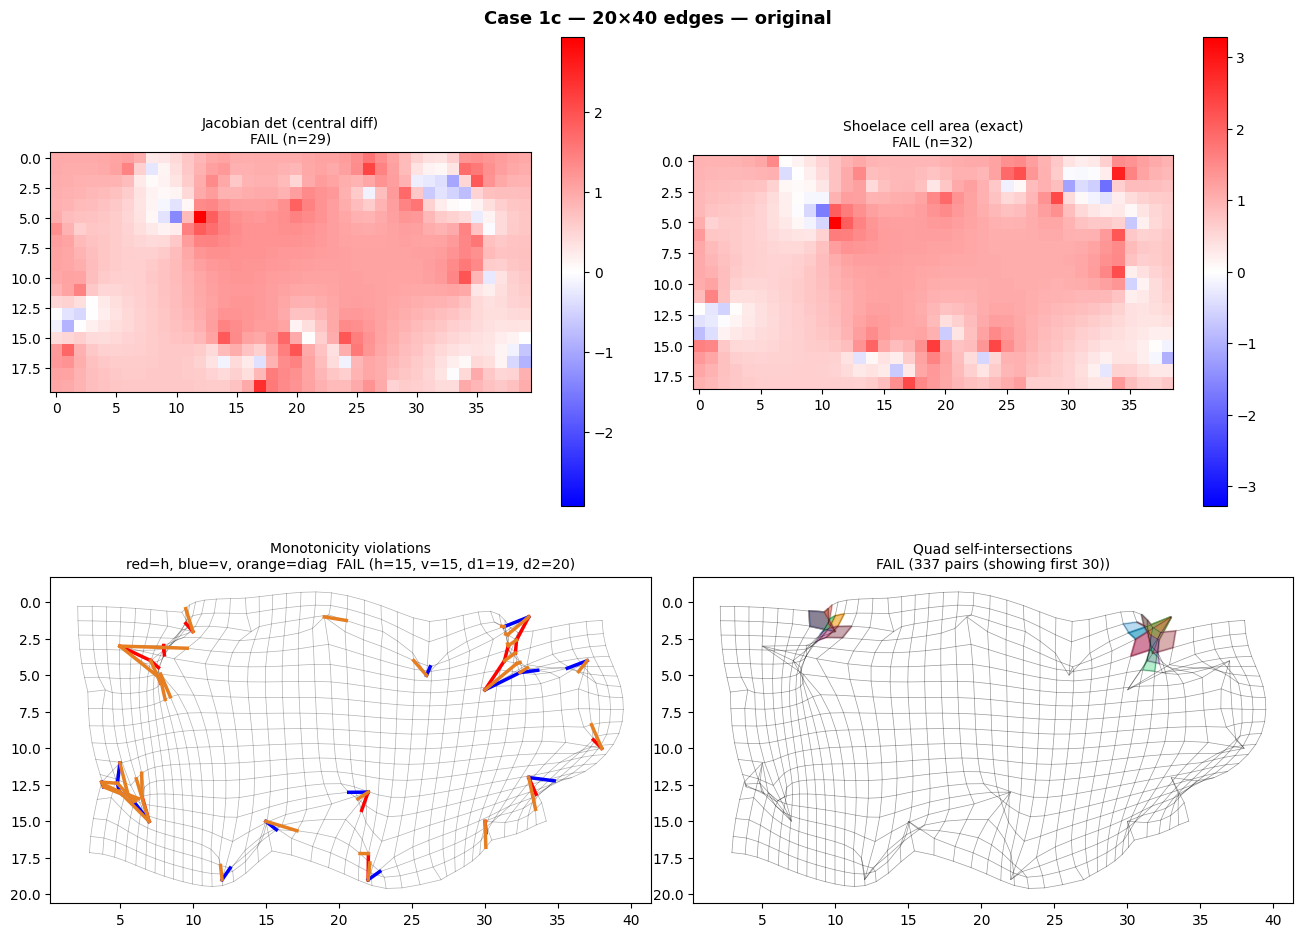


=== Case 3d — 20×20 crossing points ===
  Jdet > 0:          FAIL  (n_fail=24)
  Shoelace > 0:      FAIL  (n_fail=60)
  Monotonicity > 0:  FAIL  (h=30, v=0, d1=44, d2=0)
  Self-intersection: FAIL  (n_pairs=171)


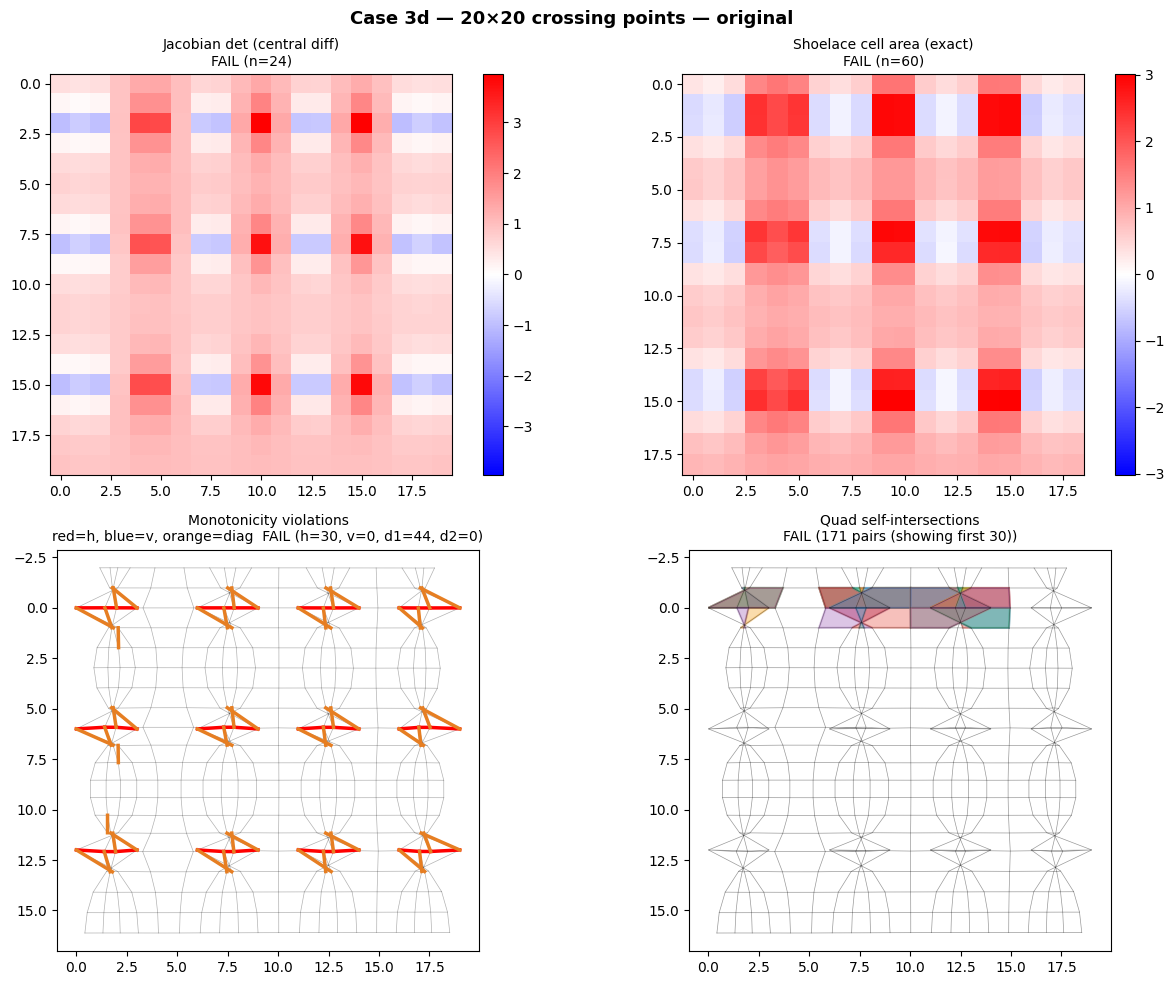

In [6]:
SYNTH_KEYS = ["01a_10x10_crossing", "01c_20x40_edges", "03d_20x20_crossing"]

orig_phis = {}
orig_deformations = {}

for key in SYNTH_KEYS:
    deformation, _, _ = make_deformation(key)
    phi = np.stack([deformation[1, 0], deformation[2, 0]])
    title = SYNTHETIC_CASES[key]['title']
    orig_phis[key] = phi
    orig_deformations[key] = deformation

    print(f"\n=== {title} ===")
    res = check_global_injectivity_2d(phi)
    plot_checks(phi, res, title=f"{title} — original")

---
## Example 3 — After correction: Jdet-only vs. Injectivity mode

After **Jdet-only** correction the Jdet constraint is satisfied, but:
- Shoelace might still reveal residual local folds (corrector uses central-diff Jdet, not shoelace).
- Monotonicity may still fail in some directions.

After **Injectivity** correction the monotonicity constraint is explicitly enforced,
which is a *sufficient* condition for global injectivity.

In [ ]:
MODES = {
    "Jdet only":      {"enforce_shoelace": False, "enforce_injectivity": False},
    "Jdet+Inject":    {"enforce_shoelace": False, "enforce_injectivity": True},
    "All constraints":{"enforce_shoelace": True,  "enforce_injectivity": True},
}

for key in SYNTH_KEYS:
    title = SYNTHETIC_CASES[key]['title']
    deformation = orig_deformations[key]

    for mode_name, flags in MODES.items():
        phi_corr = iterative_serial(
            deformation.copy(), verbose=0, threshold=THRESHOLD, **flags
        )
        print(f"\n=== {title} — after {mode_name} ===")
        res = check_global_injectivity_2d(phi_corr)
        plot_checks(phi_corr, res, title=f"{title}\nafter {mode_name} correction")

---
## Example 4 — Random DVF (spiral case, 189 initial folds)

A severely folded random field where the distinction between correction modes is most visible.

=== Random spirals — original ===
  Jdet > 0:          FAIL  (n_fail=152)
  Shoelace > 0:      FAIL  (n_fail=129)
  Monotonicity > 0:  FAIL  (h=115, v=81, d1=116, d2=114)
  Self-intersection: FAIL  (n_pairs=3201)


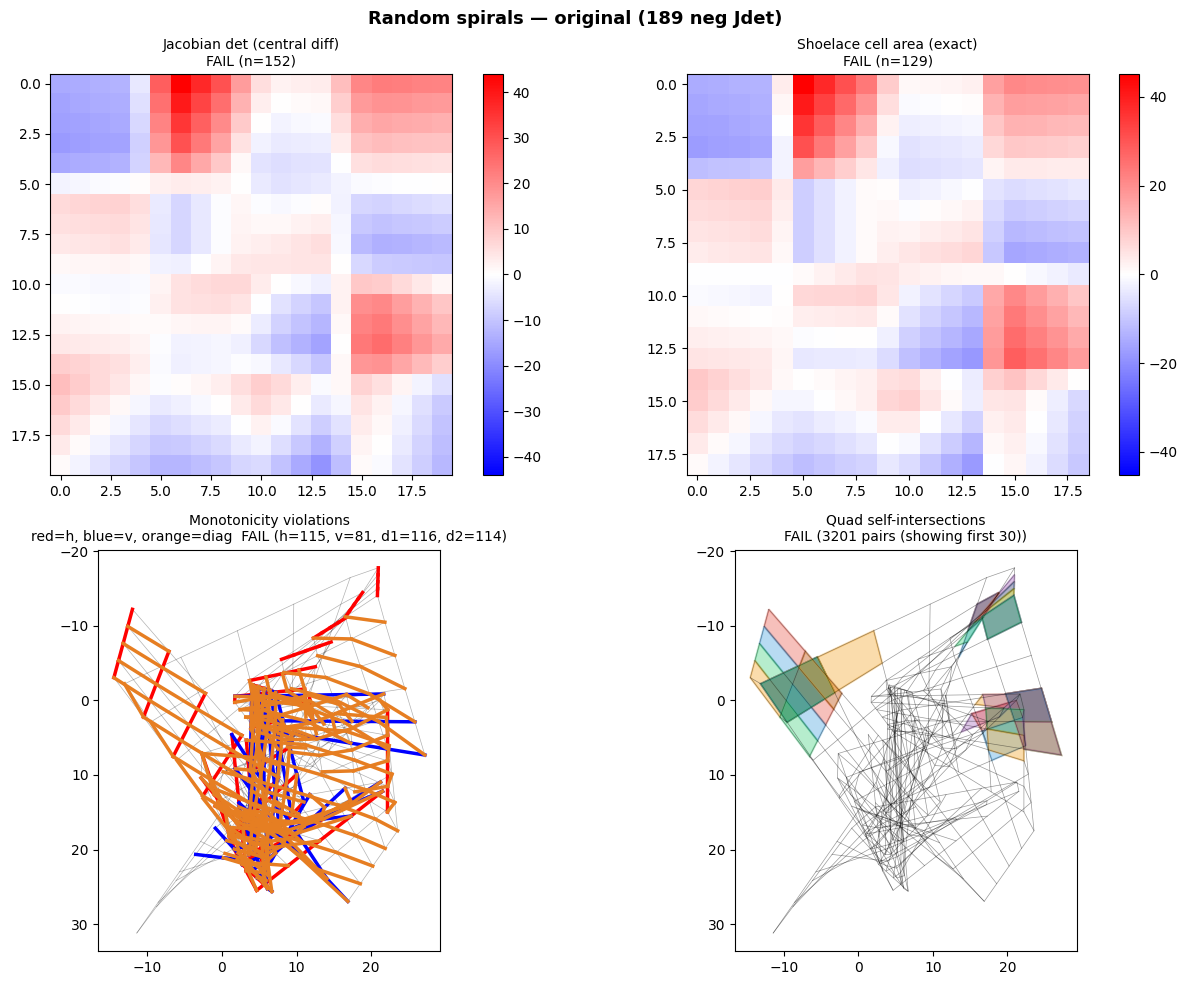


=== Random spirals — after Jdet only ===
  Jdet > 0:          OK    (n_fail=0)
  Shoelace > 0:      FAIL  (n_fail=117)
  Monotonicity > 0:  FAIL  (h=105, v=94, d1=113, d2=107)
  Self-intersection: FAIL  (n_pairs=3560)


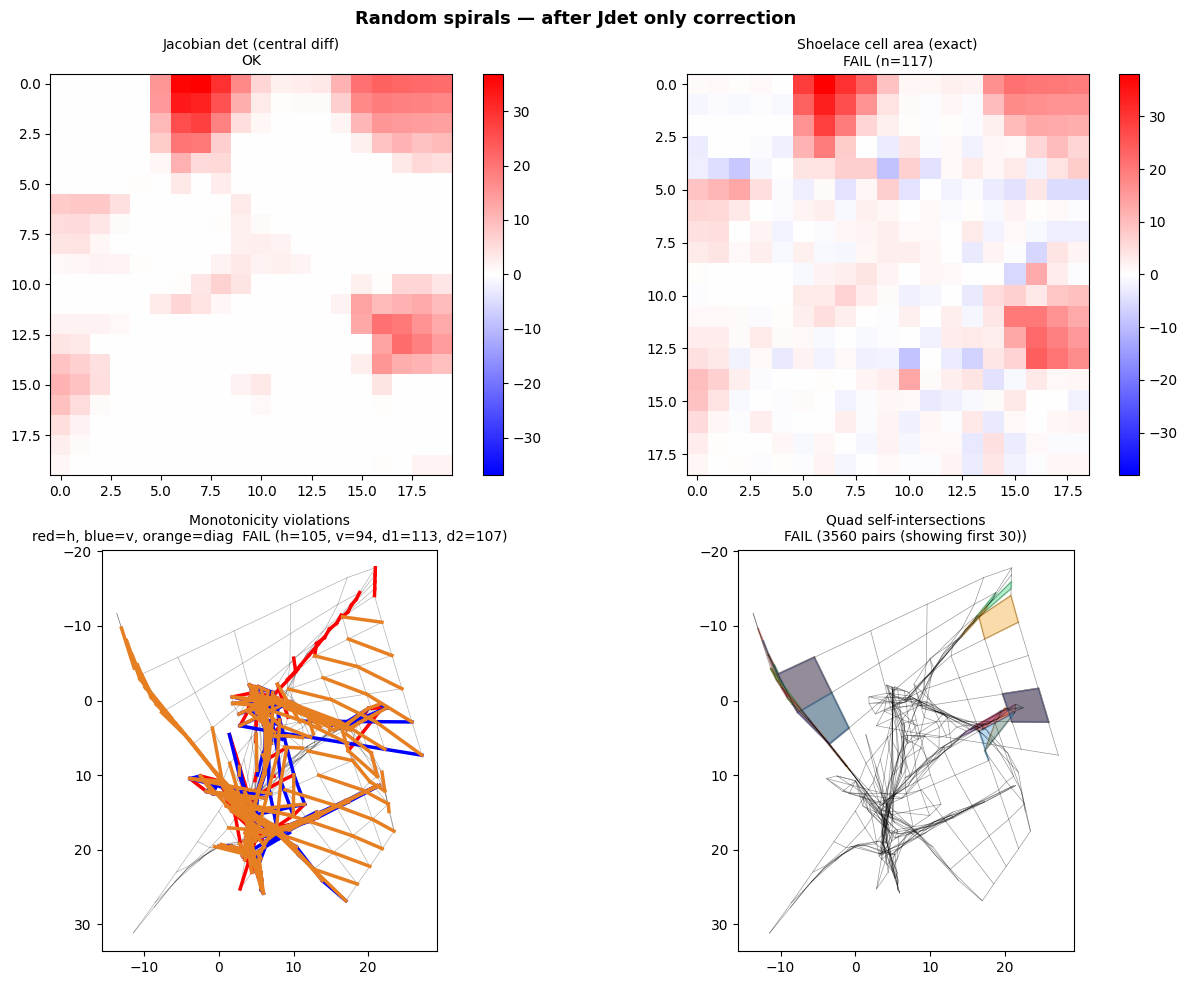

In [ ]:
deformation_sp = make_random_dvf("01e_20x20_random_spirals")
phi_sp_orig = np.stack([deformation_sp[1, 0], deformation_sp[2, 0]])

print("=== Random spirals — original ===")
res_sp_orig = check_global_injectivity_2d(phi_sp_orig)
plot_checks(phi_sp_orig, res_sp_orig, title="Random spirals — original (189 neg Jdet)")

for mode_name, flags in MODES.items():
    phi_corr = iterative_serial(
        deformation_sp.copy(), verbose=0, threshold=THRESHOLD, **flags
    )
    print(f"\n=== Random spirals — after {mode_name} ===")
    res = check_global_injectivity_2d(phi_corr)
    plot_checks(phi_corr, res, title=f"Random spirals — after {mode_name} correction")

---
## Summary table: which tests pass under which conditions?

In [ ]:
ALL_CASES = [
    ("Checkerboard A=0.7", phi_cb, None),
] + [
    (SYNTHETIC_CASES[k]['title'], orig_phis[k], orig_deformations[k])
    for k in SYNTH_KEYS
] + [
    ("Random spirals", phi_sp_orig, deformation_sp),
]

COLS = ["Jdet>0", "Shoe>0", "Mono>0", "Glob-inj"]
header = f"{'Case':<35s}  {'Stage':<16s}  " + "  ".join(f"{c:>8s}" for c in COLS)
print(header)
print("-" * len(header))

def row(label, stage, result):
    ok = lambda b: "      OK" if b else "    FAIL"
    return (f"  {label:<33s}  {stage:<16s}  "
            + "  ".join(ok(result[k]) for k in
                        ['local_jdet_ok', 'shoelace_ok', 'monotone_ok', 'globally_injective']))

# Checkerboard
print(row("Checkerboard A=0.7", "original",
          check_global_injectivity_2d(phi_cb, verbose=False)))
print()

for key in SYNTH_KEYS:
    title = SYNTHETIC_CASES[key]['title']
    deformation = orig_deformations[key]
    phi_orig = orig_phis[key]

    print(row(title, "original",
              check_global_injectivity_2d(phi_orig, verbose=False)))
    for mode_name, flags in MODES.items():
        phi_c = iterative_serial(
            deformation.copy(), verbose=0, threshold=THRESHOLD, **flags
        )
        print(row("", mode_name,
                  check_global_injectivity_2d(phi_c, verbose=False)))
    print()

# Spiral
print(row("Random spirals", "original",
          check_global_injectivity_2d(phi_sp_orig, verbose=False)))
for mode_name, flags in MODES.items():
    phi_c = iterative_serial(
        deformation_sp.copy(), verbose=0, threshold=THRESHOLD, **flags
    )
    print(row("", mode_name,
              check_global_injectivity_2d(phi_c, verbose=False)))

---
## Key takeaways

1. **Jdet (central diff) is the weakest test.** It misses local folds in alternating
   displacement patterns (the checkerboard example) because `np.gradient` averages
   over two-cell spans, cancelling out the oscillation.  The corrector's built-in
   Jdet constraint has the same blind spot.

2. **Shoelace is the right local test.** It computes the exact signed area of each
   deformed quad cell — no approximation.  Use `enforce_shoelace=True` when you
   suspect the Jdet constraint is insufficient.

3. **Monotonicity alone does *not* guarantee global injectivity of the quad mesh.**
   Horizontal (h) and vertical (v) monotonicity enforce that deformed x-coords
   increase within each row and y-coords increase within each column — independently.
   They do not prevent cells from *different rows* converging into a pinch-point and
   crossing.  The fix is **diagonal monotonicity**: requiring that for each cell (r,c),
   - `1 + dx[r, c+1] − dx[r+1, c] > 0`  (TR.x > BL.x)
   - `1 + dy[r+1, c] − dy[r, c+1] > 0`  (BL.y > TR.y)

   Together, h+v+diagonal monotonicity is sufficient to guarantee each quad cell is
   convex with positive orientation — which is the discrete analogue of the
   diffeomorphism condition.  These four conditions are now included in the
   `enforce_injectivity=True` path of the SLSQP corrector.

4. **The quad self-intersection test is the geometric ground truth.**  It directly
   tests whether any two non-adjacent deformed cells genuinely overlap.  The
   implementation uses direct edge-edge crossings + winding-number containment,
   which is correct for both convex and non-convex (pinch-point) quads.  The
   original diagonal-triangulation approach produced **false positives** at
   pinch-points because splitting a non-convex quad along its main diagonal
   over-covers the cell's true boundary and clips into nearby cells.

5. **With diagonal monotonicity enforced, "All constraints" correction should produce
   globally non-self-intersecting grids from the optimisation itself** — no
   post-processing needed.  If a self-intersection is still reported, it would
   indicate a case where the SLSQP solver did not fully converge to the constraint
   boundary (rare, and detectable by checking diagonal monotonicity violations).